EV Charging Station Usage of California City!

Import necessary libraries.

In [36]:
import pandas as pd
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
%matplotlib inline

Import dataset.

In [2]:
df = pd.read_csv('../data/dataset.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_25820\1203449715.py:1: DtypeWarning: Columns (29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/dataset.csv')


First wiew at the dataset.

In [3]:
pd.set_option('display.max_columns', None)

print("First 5 rows of data: ")
display(df.head())

print("\nInformation about data: ")
df.info(verbose=True, show_counts=True)

print("\nStatistics: numerical")
display(df.describe())

print("\nStatistics: categorical")
display(df.describe(include=['object']))

First 5 rows of data: 


,Station Name,MAC Address,Org Name,Start Date,Start Time Zone,End Date,End Time Zone,Transaction Date (Pacific Time),Total Duration (hh:mm:ss),Charging Time (hh:mm:ss),Energy (kWh),GHG Savings (kg),Gasoline Savings (gallons),Port Type,Port Number,Plug Type,EVSE ID,Address 1,City,State/Province,Postal Code,Country,Latitude,Longitude,Currency,Fee,Ended By,Plug In Event Id,Driver Postal Code,User ID,County,System S/N,Model Number
0,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/29/2011 20:17,PDT,7/29/2011 23:20,PDT,7/29/2011 23:20,3:03:32,1:54:03,6.249457,2.625,0.784,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.444572,-122.160309,USD,0.0,Plug Out at Vehicle,3,95124.0,3284.0,NaN,NaN,NaN
1,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 0:00,PDT,7/30/2011 0:02,PDT,7/30/2011 0:02,0:02:06,0:01:54,0.106588,0.045,0.013,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.444572,-122.160309,USD,0.0,Customer,4,94301.0,4169.0,NaN,NaN,NaN
2,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 8:16,PDT,7/30/2011 12:34,PDT,7/30/2011 12:34,4:17:32,4:17:28,14.951777,6.280,1.876,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.444572,-122.160309,USD,0.0,Plug Out at Vehicle,5,94301.0,4169.0,NaN,NaN,NaN
3,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 14:51,PDT,7/30/2011 16:55,PDT,7/30/2011 16:55,2:03:24,2:02:58,7.159643,3.007,0.899,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.444572,-122.160309,USD,0.0,Customer,6,94302.0,2545.0,NaN,NaN,NaN
4,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 18:51,PDT,7/30/2011 20:03,PDT,7/30/2011 20:03,1:11:24,0:43:54,1.957765,0.822,0.246,Level 2,2,J1772,NaN,250 Hamilton Ave,Palo Alto,California,94301,United States,37.444572,-122.160309,USD,0.0,Plug Out at Vehicle,7,94043.0,3765.0,NaN,NaN,NaN



Information about data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Station Name                     259415 non-null  object 
 1   MAC Address                      259415 non-null  object 
 2   Org Name                         259415 non-null  object 
 3   Start Date                       259415 non-null  object 
 4   Start Time Zone                  259415 non-null  object 
 5   End Date                         259415 non-null  object 
 6   End Time Zone                    259415 non-null  object 
 7   Transaction Date (Pacific Time)  259206 non-null  object 
 8   Total Duration (hh:mm:ss)        259415 non-null  object 
 9   Charging Time (hh:mm:ss)         259415 non-null  object 
 10  Energy (kWh)                     259415 non-null  float64
 11  GHG Savings (kg)                 259415

,Energy (kWh),GHG Savings (kg),Gasoline Savings (gallons),Port Number,EVSE ID,Postal Code,Latitude,Longitude,Fee,Plug In Event Id,Driver Postal Code,System S/N
count,259415.000000,259415.000000,259415.000000,259415.000000,1.804670e+05,259415.000000,259415.000000,259415.000000,259415.000000,2.594150e+05,251013.000000,1.804670e+05
mean,8.544277,3.588596,1.072306,1.591627,1.462973e+05,94302.315768,37.439565,-122.151264,1.097481,1.188685e+08,94170.308255,1.443790e+11
std,7.185462,3.017894,0.901776,0.491534,2.429677e+05,1.941657,0.009621,0.015382,1.934408,4.057750e+08,4249.837126,2.483280e+10
min,0.010000,0.004000,0.001000,1.000000,3.792000e+03,94301.000000,37.422104,-122.163239,0.000000,1.000000e+00,1013.000000,1.023100e+11
25%,3.784000,1.589000,0.475000,1.000000,4.358300e+04,94301.000000,37.428318,-122.162170,0.000000,1.573000e+03,94087.000000,1.231100e+11
50%,6.868634,2.885000,0.862000,2.000000,1.074270e+05,94301.000000,37.444489,-122.158272,0.000000,3.573000e+03,94304.000000,1.427410e+11
75%,11.458340,4.813000,1.438000,2.000000,1.745590e+05,94303.000000,37.446613,-122.145699,1.640000,6.340000e+03,94804.000000,1.705410e+11
max,97.360000,40.891000,12.219000,2.000000,5.535441e+06,94306.000000,37.449375,-122.112480,84.560000,1.609436e+09,99354.000000,2.002410e+11



Statistics: categorical


,Station Name,MAC Address,Org Name,Start Date,Start Time Zone,End Date,End Time Zone,Transaction Date (Pacific Time),Total Duration (hh:mm:ss),Charging Time (hh:mm:ss),Port Type,Plug Type,Address 1,City,State/Province,Country,Currency,Ended By,User ID,County,Model Number
count,259415,259415,259415,259415,259415,259415,259415,259206,259415,259415,259406,259415,259415,259415,259415,259415,257627,259167,251738,174750,180467
unique,47,83,2,244798,3,244159,3,240905,31025,22473,2,2,20,1,1,1,4,16,27698,2,10
top,PALO ALTO CA / HAMILTON #2,000D:6F00:015A:9D76,City of Palo Alto,10/25/2019 18:21,PDT,8/27/2015 9:57,PDT,8/11/2017 20:01,1:20:51,1:26:45,Level 2,J1772,250 Hamilton Ave,Palo Alto,California,United States,USD,Plug Out at Vehicle,283441,Santa Clara County,CT4020-HD-GW
freq,23721,14888,236865,4,166763,6,166791,15,36,76,254727,254734,38609,259415,259415,259415,257613,210721,949,147263,84886


In [4]:
print("Розподіл валют у датасеті:")
print(df['Currency'].value_counts())

Розподіл валют у датасеті:
Currency
USD    257613
EUR         8
MXN         5
CAD         1
Name: count, dtype: int64


As we can see there are some features that contain one unique value (City, State/Province, Country). Also we have the features that contain ordinal numbers (EVSE ID, Plug In Event Id, System S/N, MAC Address). And there are some features that are  linear transformations of Energy (kWh) (GHG Savings, Gasoline Savings). 
That`s why I remove all these features!

In [5]:
df.drop(columns=['City', 'State/Province', 'Country', 'System S/N', 'Plug In Event Id', 'EVSE ID', 'GHG Savings (kg)', 'Gasoline Savings (gallons)', 'MAC Address', 'Currency'], errors='ignore', inplace=True)
df.shape

(259415, 23)

View at our missing values.

In [6]:
missing_valuse = df.isnull().sum()
print(missing_valuse)

Station Name                           0
Org Name                               0
Start Date                             0
Start Time Zone                        0
End Date                               0
End Time Zone                          0
Transaction Date (Pacific Time)      209
Total Duration (hh:mm:ss)              0
Charging Time (hh:mm:ss)               0
Energy (kWh)                           0
Port Type                              9
Port Number                            0
Plug Type                              0
Address 1                              0
Postal Code                            0
Latitude                               0
Longitude                              0
Fee                                    0
Ended By                             248
Driver Postal Code                  8402
User ID                             7677
County                             84665
Model Number                       78948
dtype: int64


We can see that we have a large number of missing values (County = 33%, Model Number = 30.5). Thats why I think that it would be a good idea to delete these features.
In features where are a small number of miisng values (Transaction Date (Pacific Time) = 0.08%, Port Type = 0.003, 'Ended By = 0.096%), so I delete rows in order to equate these features. 
In these features (User ID = 2.96%, Driver Postal Code = 3.24%). There aren`t so large amounts so I fill these feature with values = 0.

In [7]:
df.dropna(subset=['Transaction Date (Pacific Time)', 'Port Type', 'Ended By'], inplace=True)

df.drop(columns=['County', 'Model Number'], inplace=True)

df['User ID'] = df['User ID'].fillna(0)
df['Driver Postal Code'] = df['Driver Postal Code'].fillna(0)


In order to change the categorical features (hh:mm:ss) to numerical I create a useful function which converts (hh:mm:ss) into numerical (minutes). After that change Total Duration, Charging Time on these numerical features. 

In [8]:
def time_to_minutes(time_str):
    if pd.isna(time_str) or time_str == "":
        return 0
    try:
        time_string = time_str
        parts = time_string.split(':')
        h, m, s = map(float, parts)
        result = h * 60 + m + (s / 60)
        return result
    except:
        return 0
    
df['duration_min'] = df['Total Duration (hh:mm:ss)'].apply(time_to_minutes)
df['charging_min'] = df['Charging Time (hh:mm:ss)'].apply(time_to_minutes)

display(df[['Total Duration (hh:mm:ss)', 'duration_min', 'Charging Time (hh:mm:ss)', 'charging_min']].head())
df.drop(columns=['Total Duration (hh:mm:ss)', 'Charging Time (hh:mm:ss)'], inplace=True)

,Total Duration (hh:mm:ss),duration_min,Charging Time (hh:mm:ss),charging_min
0,3:03:32,183.533333,1:54:03,114.050000
1,0:02:06,2.100000,0:01:54,1.900000
2,4:17:32,257.533333,4:17:28,257.466667
3,2:03:24,123.400000,2:02:58,122.966667
4,1:11:24,71.400000,0:43:54,43.900000


Exploratory Data Analysis. Сorrelation Matrix (Heatmap).

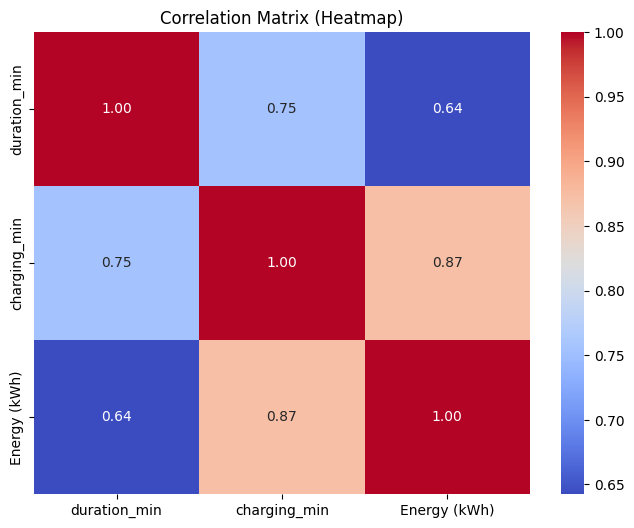

In [9]:
cols_for_corr = ['duration_min', 'charging_min', 'Energy (kWh)']
corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Heatmap)')
plt.show()

In order to understand the structure of data i built Pearson`s correlation matrix. 
I see strong correlation (0.87) between charging_min and Energy (kWh): This confirms the physical logic of the process: the amount of energy transferred is directly proportional to the time of active charging.
I see moderate correlation (0.75) between duration_min and Energy (kWh): The connection is weaker than in the previous case. This indicates the presence of "noise" - sessions where the machine occupied a slot (duration) but did not consume energy (Energy).
The high correlation between charging_min and Energy (kWh) indicates a potential multicollinearity problem. However, for the clustering task (Unsupervised Learning), we keep both features because the difference between them (idle time without charging) is critical for isolating the target driver segments.


Scatter plot for visual confirmation of our hypothesis.

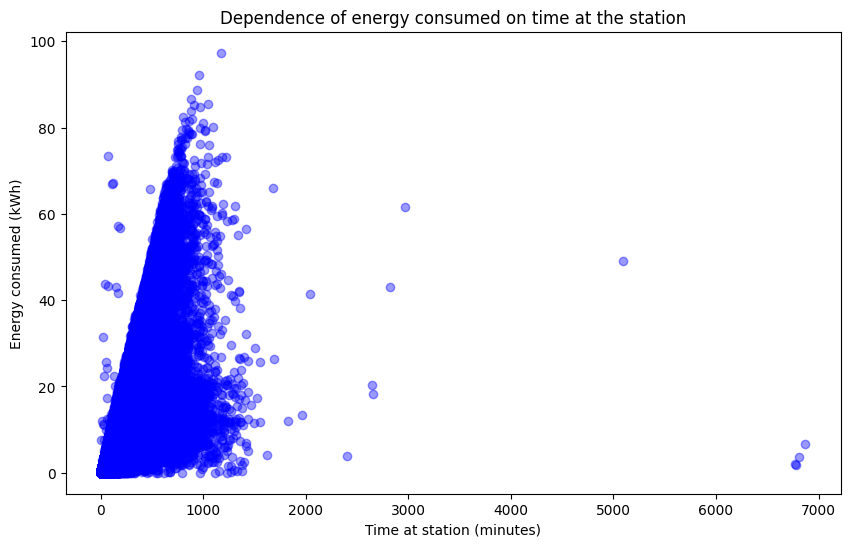

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(x = df['duration_min'], y = df['Energy (kWh)'], alpha=0.4, color = 'blue')
plt.title('Dependence of energy consumed on time at the station')
plt.xlabel('Time at station (minutes)')
plt.ylabel('Energy consumed (kWh)')
plt.show()

Before I threw the data into the algorithm, I decided to just look at it. On the horizontal, we have time in minutes, on the vertical, real kilowatts.
Here's what immediately catches your eye:

"Adequate diagonal": See that clear line going up? These are our ideal customers. They came, charged up, and left. The longer they stand, the more energy they get. Everything is fair here: both for the driver and for the business.

"Ghosts" in the parking lot (Horizontal tail): And here the most interesting thing begins. A huge number of points "crawled" to the right, but almost did not rise up. What does this mean? These are people who occupy a place for hours, but take a negligible amount of energy. Mathematically, we see the problem of overstays - when charging turns into ordinary parking.

Extreme record holders: Look at these single points in the region of 5000-7000 minutes. That's 4-5 days! Most likely, someone simply left their car near the office or home and went on vacation. For a business, such a client is a "traffic jam" that prevents you from earning.

This picture clearly shows: charging only for kilowatts is a path to the black. While one driver "sleeps" at the station for 5 days, dozens of others cannot charge. This graph is my main argument why we need clustering and new idle tariffs.


StandardScaler.

In [24]:
from sklearn.preprocessing import StandardScaler

features = ['duration_min', 'Energy (kWh)']

scaler = StandardScaler()

scaled_values = scaler.fit_transform(df[features])

X = pd.DataFrame(scaled_values, columns=features)

display(X.head())

,duration_min,Energy (kWh)
0,0.258331,-0.319587
1,-1.108161,-1.174465
2,0.815672,0.891479
3,-0.194572,-0.192920
4,-0.586218,-0.916844


The K-Means algorithm works like a regular ruler — it measures the distance between points . To prevent our minutes (which are thousands) from being crushed by kilowatts (which are tens), we compress them all into the same range. StandardScaler will make the average of each column zero, and all other data will be deviations from it (usually from -3 to 3).

Training the kmeans model.

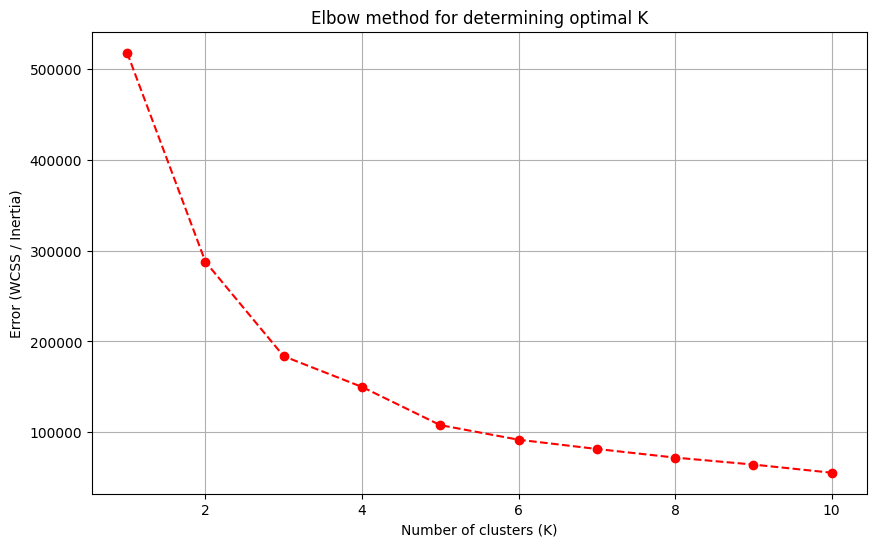

In [25]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('Elbow method for determining optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Error (WCSS / Inertia)')
plt.grid(True)
plt.show()

Initially, I needed to know how many clusters there should be for the model to work best. For this I used the Elbow Method.

Training the final kmeans model.

In [33]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init='auto')

df['Cluster'] = kmeans_final.fit_predict(X)

print(df['Cluster'].value_counts())

Cluster
2    103345
3    100947
0     45606
1      9127
Name: count, dtype: int64


After cleaning and preparing the data, I used the K-Means algorithm to divide all sessions into 4 logical groups. Here is how our "heroes" were distributed:

Distribution by clusters:

Cluster 2 (103,345 sessions): The largest group. Most likely, these are our "ideal" or fast customers.

Cluster 3 (100,947 sessions): The second largest group, which represents standard behavior and average charging time.

Cluster 0 (45,606 sessions): A noticeable segment of drivers who show specific patterns (heavy users taking more energy).

Cluster 1 (9,127 sessions): The smallest but most interesting group. These are our anomalies. This is where the same arrogant parking drivers who have been standing for days usually "hide".

Visualization of segmentation results

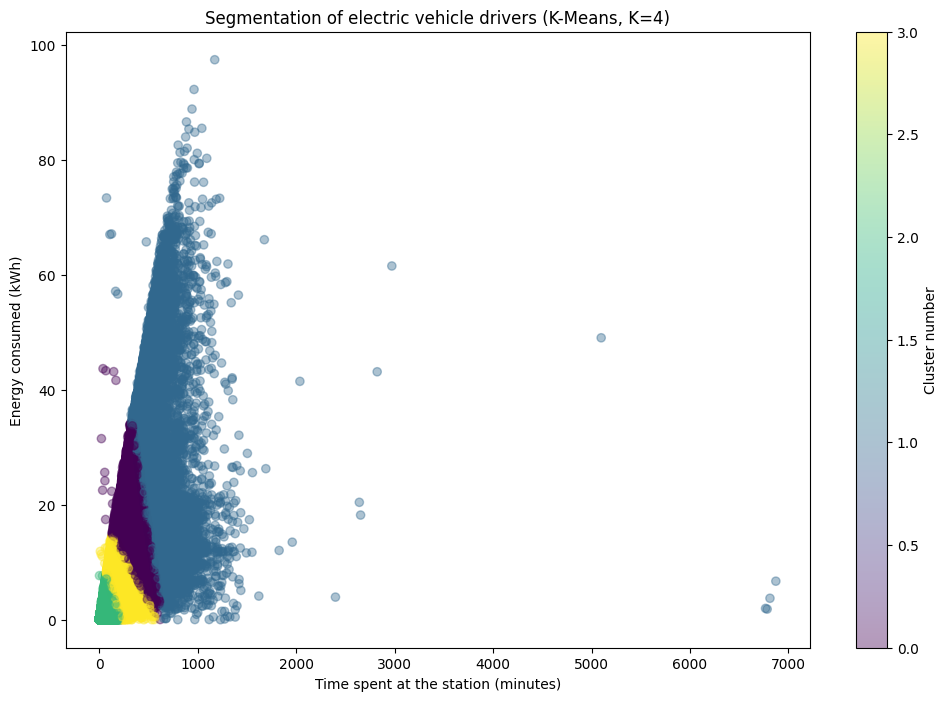

In [34]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(x = df['duration_min'], y = df['Energy (kWh)'], c = df['Cluster'], alpha = 0.4, cmap = 'viridis')
plt.title('Segmentation of electric vehicle drivers (K-Means, K=4)')
plt.xlabel('Time spent at the station (minutes)')
plt.ylabel('Energy consumed (kWh)')
plt.colorbar(scatter, label='Cluster number')
plt.show()

As we can see, the K-Means algorithm successfully segmented the sessions into 4 functional groups based solely on connection time and energy consumed.

Cluster 0 — "Heavy Users" (High Energy, Proportional Time):
These drivers spend a significant amount of time at the station (averaging 4 hours) but consume a proportional amount of energy (~16.6 kWh). These are vehicles with larger batteries coming for a deep charge. For the business, these are valuable, active customers.

Clusters 2 & 3 — "Standard & Quick Sessions":
This is the core user base. Cluster 2 represents "quick snacks" (around 1 hour, ~3.3 kWh), while Cluster 3 represents standard behavior (about 2.5 hours, ~8.5 kWh). They use the station exactly as intended: plug in, do some shopping or errands, and leave when finished.

Cluster 1 — "The Overstayers":
This is where the main business problem hides! Look at the time distribution for this group. While they consume a fair amount of energy, their connection time stretches enormously—averaging almost 11 hours, with extreme cases hitting 1000+ minutes. For most of this time, the car is already fully charged, but it continues to block the station, acting as a free parking space. This prevents other customers from charging and directly cuts into the city's revenue.

Proposed Business Solutions:

Idle Fees: The most effective method (used by networks like Tesla). When the battery is full, the driver gets a 30-minute grace period. After that, every minute of idle time incurs a specific fee.

Push Notifications: Automated alerts sent to the driver's phone: "Your charging is complete. Please move your vehicle to make room for others."

Time Limits: Physical signage and software restrictions that impose a maximum stay (e.g., 4 hours), regardless of the charge level.

Mean values duration_min, charging_min, Energy (kWh) for each cluster:

In [35]:
cluster_stats = df.groupby('Cluster')[['duration_min', 'Energy (kWh)']].mean()
cluster_stats['Counts of sessions'] = df['Cluster'].value_counts()
cluster_stats = cluster_stats.round(2)
print(cluster_stats)

         duration_min  Energy (kWh)  Counts of sessions
Cluster                                                
0              240.19         16.61               45606
1              643.62         27.32                9127
2               60.70          3.33              103345
3              154.07          8.54              100947


Let's look at these numbers, because that's where the real business value is:

Cluster 2 (103,345 sessions): "Coffee break"  > This is the most massive group. Drivers stay for just about an hour (61 min) and consume a minimum amount of energy (3.3 kWh). This is an ideal customer rotation for the city — people arrive, recharge while grabbing a coffee or doing a quick errand, and leave.

Cluster 3 (100,947 sessions): "Standard shopping"  > These are also standard, adequate customers. They occupy the station for about 2.5 hours (154 min) and take around 8.5 kWh. They represent the typical, expected use case for a destination charging station.

Cluster 0 (45,606 sessions): "Heavy Users"  > They stay for about 4 hours (240 min) and consume a solid 16.6 kWh. These are drivers with larger batteries or those who arrived with a low state of charge. They use the station exactly as intended, taking in a lot of energy over a proportional amount of time.

Cluster 1 (9,127 sessions): "Cheeky parking attendants" (Overstayers)  > And here is the main problem we've been looking for! Look at the extreme numbers: a person occupies the station for almost 11 hours (644 minutes), but consumes only 27.3 kWh. On a standard Level 2 charger, delivering 27 kWh takes roughly 4 hours. This means that for the remaining 7 hours, the station is simply blocked by an already fully charged vehicle! Even though it's the smallest group, these 9,000+ sessions represent colossal lost profits for the network owner and prevent other EV drivers from charging.

Export the model.

In [29]:
#save train model
joblib.dump(kmeans_final, '../models/kmeans_ev_model.pkl')
#save our scaler
joblib.dump(scaler, '../models/ev_scaler.pkl')

print("Successfully exported all the files")

Successfully exported all the files
